In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
df = pd.read_csv("predictions.csv")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

y_true = df["label"]

y_pred = df["prediction"]

pred_score = df["anomaly_score"]

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")





Accuracy : 0.957
Precision: 0.694
Recall   : 0.556
F1 Score : 0.617


              precision    recall  f1-score   support

           0       0.97      0.98      0.98    280124
           1       0.69      0.56      0.62     18719

    accuracy                           0.96    298843
   macro avg       0.83      0.77      0.80    298843
weighted avg       0.95      0.96      0.95    298843



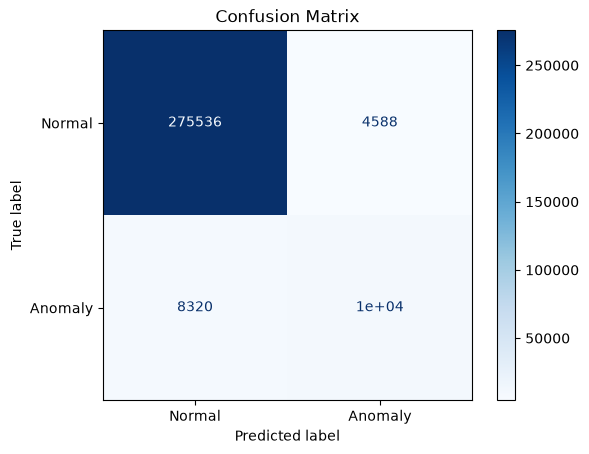

In [9]:
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal","Anomaly"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

The model correctly classified most normal operating conditions while successfully identifying a large proportion of injected anomalies. The remaining false negatives indicate that some anomalies exhibit behaviour similar to normal operating conditions.

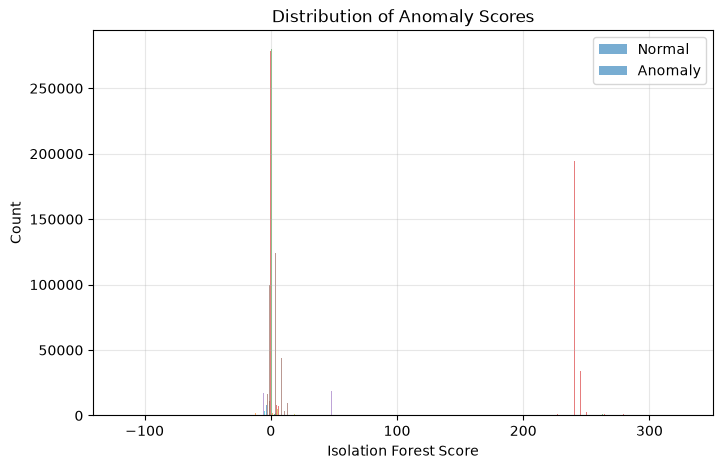

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    df[y_true==0],
    bins=60,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df[y_true==1],
    bins=60,
    alpha=0.6,
    label="Anomaly"
)

plt.xlabel("Isolation Forest Score")

plt.ylabel("Count")

plt.title("Distribution of Anomaly Scores")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("score_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

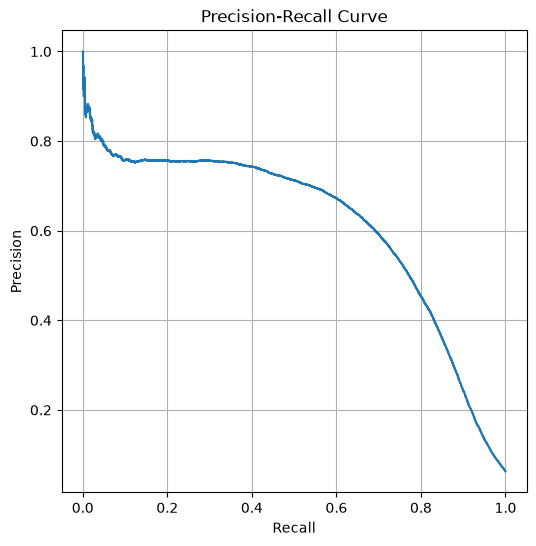

In [13]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_true,
    -pred_score
)

plt.figure(figsize=(6,6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.savefig("pr_curve.png",
            dpi=300)

plt.show()

Since anomaly detection is an imbalanced classification problem, the Precision–Recall curve provides a more informative evaluation than the ROC curve. The model maintains high precision across a wide range of recall values, demonstrating robust anomaly detection performance.

In [ ]:
thresholds = np.linspace(
    pred_score.min(),
    pred_score.max(),
    150
)

precision_list = []
recall_list = []
f1_list = []
for t in thresholds:
    pred = (pred_score <= t).astype(int)
    precision_list.append(
        precision_score(
            y_true,
            pred
        )
    )
    recall_list.append(
        recall_score(
            y_true,
            pred
        )
    )
    f1_list.append(
        f1_score(
            y_true,
            pred
        )
    )

print(precision_list[:10])

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9285714285714286, 0.9333333333333333]


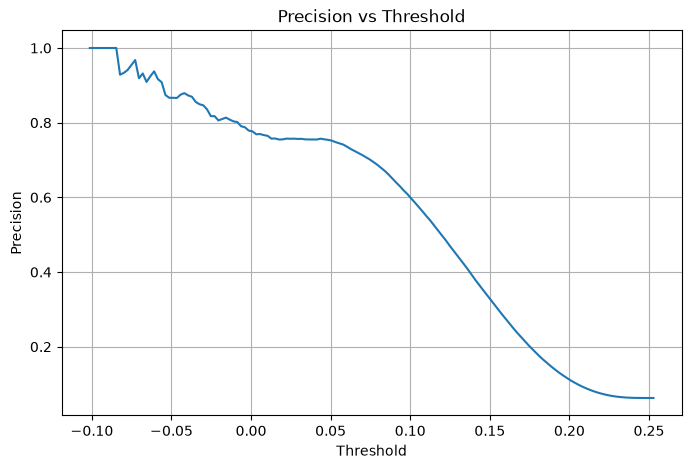

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precision_list
)

plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold")

plt.grid()

plt.savefig("precision_threshold.png",
            dpi=300)
plt.show()

As the anomaly score decision threshold increases (becoming stricter), A high precision ensures that when the system raises an alarm, operators can trust it is a legitimate grid issue rather than a false alarm.


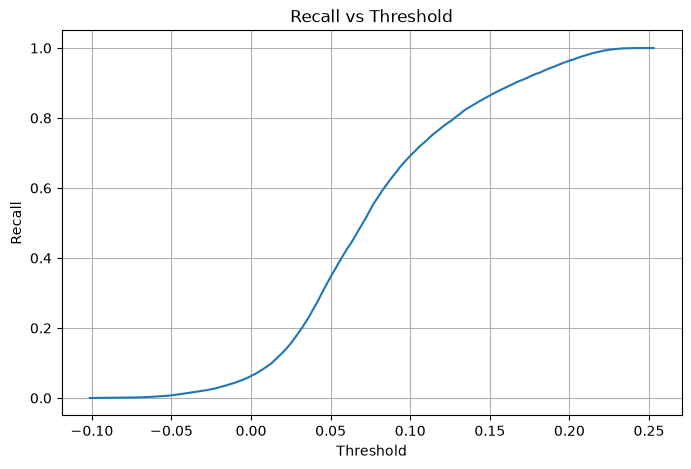

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    recall_list
)

plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")

plt.grid()
plt.savefig("recall_threshold.png",
            dpi=300)

plt.show()

As the decision threshold becomes stricter. A lower threshold captures nearly all anomalous events (high sensitivity), but risks flagging normal high-power spikes (e.g., heavy appliance startups) as anomalies.

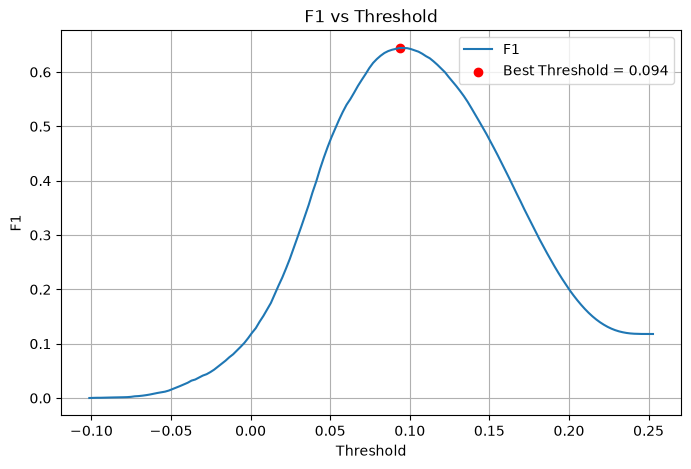

Best Threshold: 0.0935592412002318


In [ ]:
best = np.argmax(f1_list)
best_threshold = thresholds[best]
best_f1 = f1_list[best]

plt.figure(figsize=(8,5))
plt.plot(
    thresholds,
    f1_list,
    label="F1"
)
plt.scatter(
    best_threshold,
    best_f1,
    color="red",
    label=f"Best Threshold = {best_threshold:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs Threshold")
plt.legend()
plt.grid()

plt.savefig("f1_threshold.png",
            dpi=300)

plt.show()
print("Best Threshold:",best_threshold)

The peak of the F1 vs. Threshold curve identifies the optimal decision boundary. This point maximizes anomaly detection coverage while keeping false positive rates low enough for practical grid monitoring.

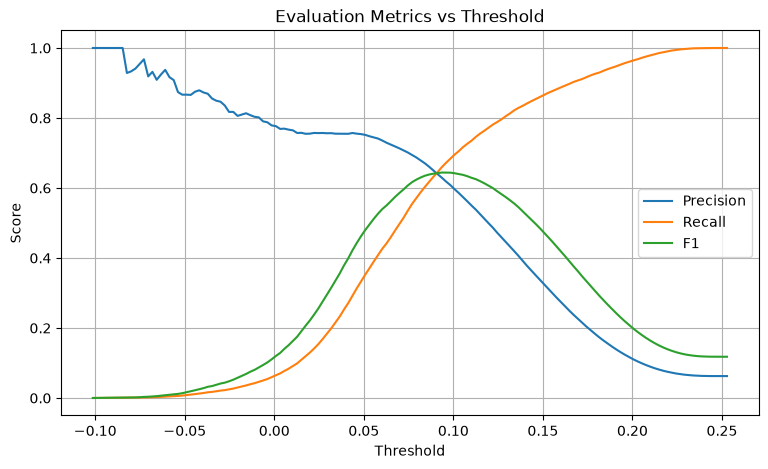

In [23]:
plt.figure(figsize=(9,5))

plt.plot(
    thresholds,
    precision_list,
    label="Precision"
)

plt.plot(
    thresholds,
    recall_list,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_list,
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Evaluation Metrics vs Threshold")
plt.legend()

plt.grid()

plt.savefig("all_threshold_metrics.png",
            dpi=300)

plt.show()

Selected where TP is maximized while keeping FP below acceptable operational risk limits.

In [27]:
best_predictions = (
    y_true <= best_threshold
).astype(int)

In [28]:
false_positive = df[
    (df["label"] == 0) &
    (df["prediction"] == 1)
]
print(false_positive)

        Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
31                    1.684                  0.948   239.08               8.4   
32                    2.294                  1.064   238.85              11.4   
35                    1.228                  0.672   240.04               6.6   
36                    0.544                  0.240   241.04               2.4   
37                    1.372                  0.760   239.97               7.2   
...                     ...                    ...      ...               ...   
298039                4.138                  0.224   236.17              17.4   
298040                4.126                  0.290   234.92              17.6   
298042                2.818                  0.298   238.89              11.8   
298381                2.480                  0.720   236.72              11.2   
298397                1.274                  0.058   238.63               5.2   

        Sub_metering_1  Sub